# 06 — Race-Condition Analysis: Monaco GP 2026

Goal of this notebook:
1. Apply the race pipeline to Monaco 2026 R (ANT)
2. Track lap-by-lap thermal and wear evolution across all three analyzable stints
3. Compare race results to the Phase 1a qualifying baseline (same driver, same circuit)
4. Document what the regime-flip hypothesis looks like in race conditions
5. Identify what this tells us about Phase 1b chunk 2 priorities

## Headline finding (preview)

Single-lap qualifying analysis systematically overestimates race-stint brake wear at Monaco. Phase 1a's Q3 pole lap predicted 27 mg/lap; the race pipeline gives 24 mg/lap averaged across 65 racing laps — a ~12% per-lap reduction, despite the race car carrying 60+ kg more fuel. The fuel-mass effect (heavier → more energy per stop) is real but is outweighed by racing-pace driving style being less aggressive than a Q3 push lap.

The regime-flip hypothesis from the Phase 1b scope (oxidative wear overtaking mechanical above ~900°C) is **not confirmed at Monaco even under race conditions**. Peak disc temperature reaches 780°C; oxidative wear contributes < 0.001% of total. Testing the hypothesis requires either hotter circuits or fundamentally different conditions.

## Race context

The Monaco 2026 race was disrupted by safety car (~lap 60) and red flag (~laps 61-69). Stints 3 and 4 were almost entirely consumed by these events and produced zero analyzable laps. The model correctly excludes 13 laps total (1 standing-start + 12 SC/red flag/NaT). The remaining 65 laps span three stints: Medium (36 laps), Hard (22 laps), Soft (7 laps).

In [1]:
# Load and process

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

from src.analysis.race_pipeline import run_race
from src.analysis.pipeline import run_session  # for Q comparison

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

fastf1.Cache.enable_cache('../data/raw')

# Race
r_race = run_race(2026, 'Monaco', 'ANT', verbose=False)

# Qualifying baseline (from Phase 1a)
r_quali = run_session(2026, 'Monaco', 'Q', verbose=False)

per_lap = r_race['per_lap'].copy()
per_stint = r_race['per_stint'].copy()

# Add a sequential "analyzed stint" number for cleaner plotting
# (the original Stint column has gaps where stints 3-4 vanished)
stint_remap = {s: i + 1 for i, s in enumerate(sorted(per_stint['stint'].unique()))}
per_lap['stint_seq'] = per_lap['stint'].map(stint_remap)
per_stint['stint_seq'] = per_stint['stint'].map(stint_remap)

print(f"Race: {r_race['n_analyzed_laps']}/{r_race['n_race_laps']} laps analyzed")
print(f"Qualifying baseline: {r_quali['driver']} {r_quali['lap_time_s']:.3f}s, "
      f"T_max={r_quali['T_max_C']:.0f}°C, wear={r_quali['wear_total_mg_per_disc']:.1f}mg")
print(f"\nStint summary:")
print(per_stint[['stint', 'stint_seq', 'compound', 'n_laps',
                  'T_mean_C', 'T_max_C', 'wear_total_mg',
                  'E_brake_total_MJ']].to_string(index=False))

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '10', '6', '81', '30', '41', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']
core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data

Race: 65/78 laps analyzed
Qualifying baseline: ANT 72.051s, T_max=798°C, wear=27.0mg

Stint summary:
 stint  stint_seq compound  n_laps   T_mean_C    T_max_C  wear_total_mg  E_brake_total_MJ
     1          1   MEDIUM      36 644.576739 779.765647     890.446778        176.954546
     2          2     HARD      22 630.858000 752.564768     524.156061        104.149132
     5          3     SOFT       7 614.970277 727.088457     158.754154         31.696190


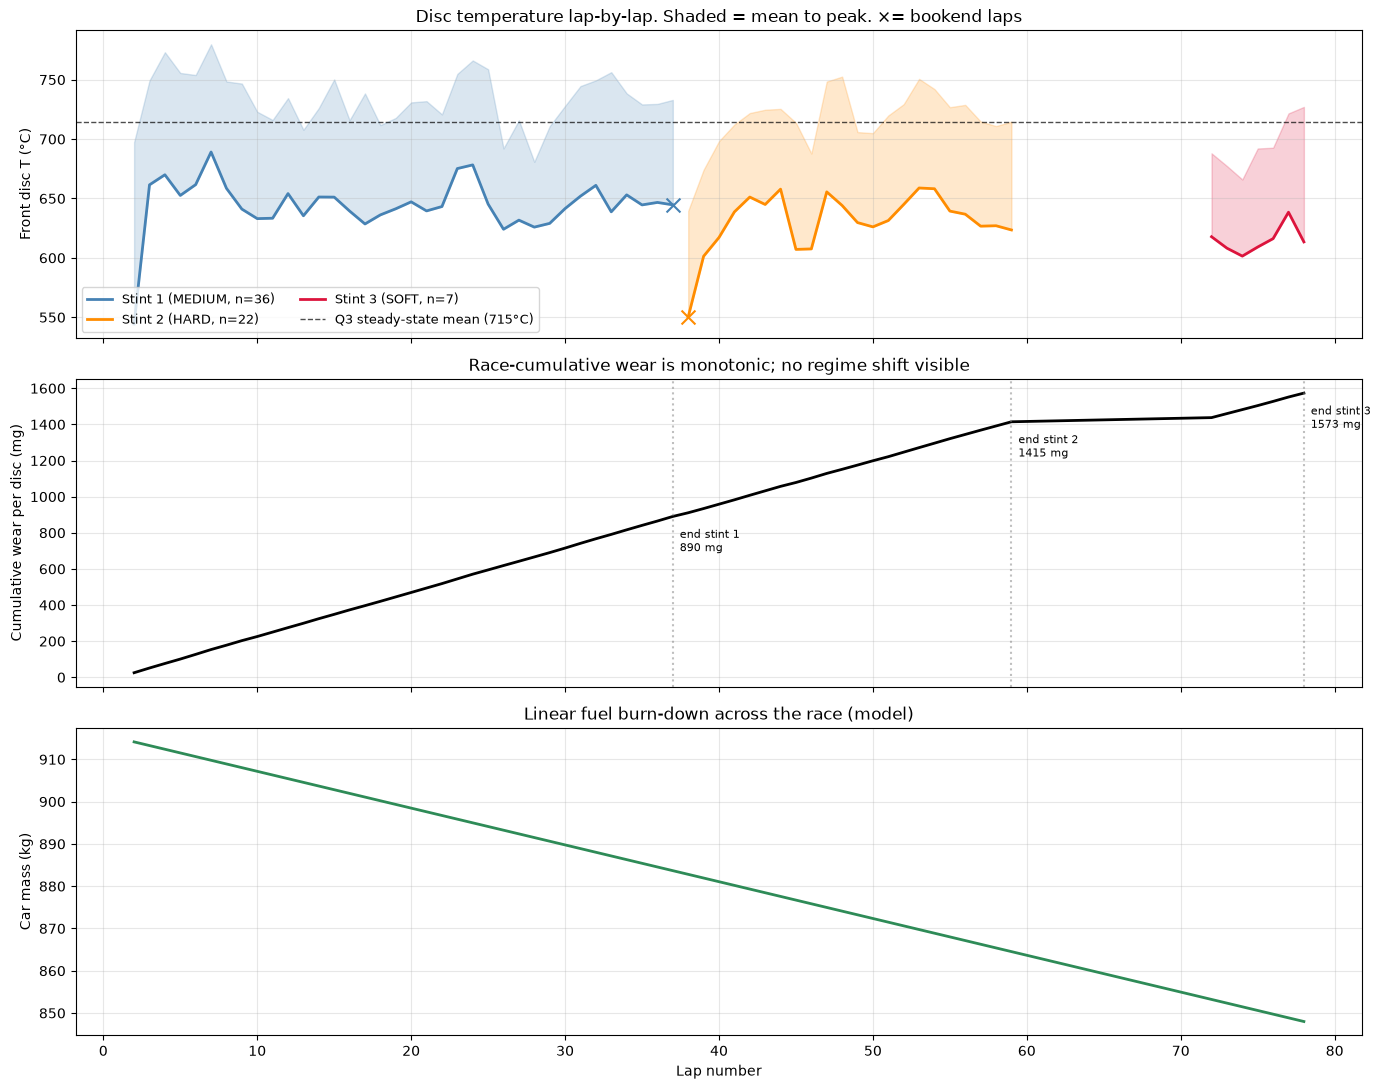

In [2]:
# Lap-by-lap evolution. Three panels: temperature evolution, wear accumulation, and the underlying mass evolution.

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Color-code by stint
stint_colors = {1: 'steelblue', 2: 'darkorange', 3: 'crimson'}

# ── Top: mean and peak disc temperature per lap ──────────────────────
for sseq, group in per_lap.groupby('stint_seq'):
    color = stint_colors.get(sseq, 'gray')
    compound = group['compound'].iloc[0]
    label = f"Stint {sseq} ({compound}, n={len(group)})"
    axes[0].plot(group['lap_number'], group['T_disc_mean_C'],
                  '-', color=color, linewidth=2, label=label)
    axes[0].fill_between(group['lap_number'],
                          group['T_disc_mean_C'], group['T_disc_max_C'],
                          color=color, alpha=0.2)
    # Mark bookend laps
    bookends = group[group['is_bookend_lap']]
    if len(bookends) > 0:
        axes[0].scatter(bookends['lap_number'], bookends['T_disc_mean_C'],
                         color=color, marker='x', s=100, zorder=5,
                         label='_nolegend_')

axes[0].axhline(r_quali['T_mean_C'], color='black', linestyle='--',
                 linewidth=1, alpha=0.7,
                 label=f"Q3 steady-state mean ({r_quali['T_mean_C']:.0f}°C)")
axes[0].set_ylabel('Front disc T (°C)')
axes[0].set_title('Disc temperature lap-by-lap. Shaded = mean to peak. ×= bookend laps')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='lower left', ncol=2, fontsize=9)

# ── Middle: cumulative wear ──────────────────────────────────────────
axes[1].plot(per_lap['lap_number'], per_lap['wear_total_cum_mg'],
              '-', color='black', linewidth=2)
# Annotate end of each stint
for sseq, group in per_lap.groupby('stint_seq'):
    end_lap = group['lap_number'].iloc[-1]
    end_wear = group['wear_total_cum_mg'].iloc[-1]
    axes[1].axvline(end_lap, color='gray', linestyle=':', alpha=0.5)
    axes[1].annotate(f"end stint {sseq}\n{end_wear:.0f} mg",
                      (end_lap, end_wear),
                      xytext=(5, -25), textcoords='offset points', fontsize=8)
axes[1].set_ylabel('Cumulative wear per disc (mg)')
axes[1].set_title('Race-cumulative wear is monotonic; no regime shift visible')
axes[1].grid(True, alpha=0.3)

# ── Bottom: car mass evolution ───────────────────────────────────────
axes[2].plot(per_lap['lap_number'], per_lap['m_car_kg'],
              '-', color='seagreen', linewidth=2)
axes[2].set_ylabel('Car mass (kg)')
axes[2].set_xlabel('Lap number')
axes[2].set_title('Linear fuel burn-down across the race (model)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

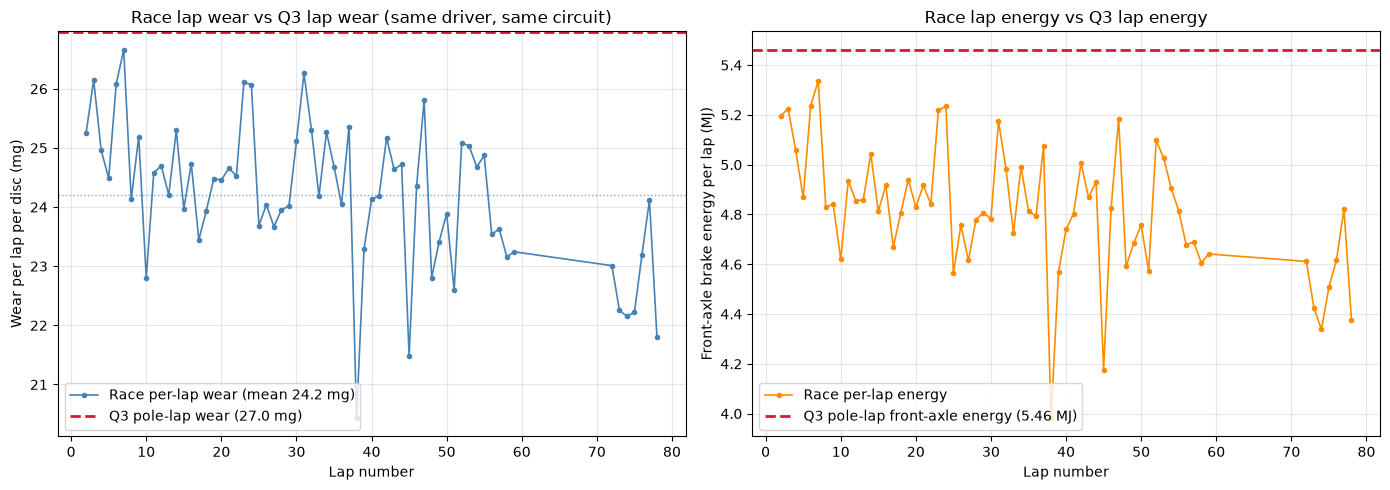


Race vs Q3 comparison (Monaco 2026, ANT):
  Wear per lap:
    Q3 pole lap:     26.95 mg
    Race mean:       24.21 mg (-10.2%)
  Front-axle energy per lap:
    Q3 pole lap:     5.46 MJ
    Race mean:       4.81 MJ (-11.9%)
  Peak disc T:
    Q3 steady state: 798 °C
    Race max:        780 °C


In [3]:
# Race vs Q comparison. lay the race temperature trace alongside the qualifying steady-state for the same driver, same circuit.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: per-lap wear comparison ────────────────────────────────────
race_per_lap_wear = per_lap['wear_mech_lap_mg'] + per_lap['wear_ox_lap_mg']
axes[0].plot(per_lap['lap_number'], race_per_lap_wear,
              '-o', color='steelblue', markersize=3, linewidth=1.2,
              label=f"Race per-lap wear (mean {race_per_lap_wear.mean():.1f} mg)")
axes[0].axhline(r_quali['wear_total_mg_per_disc'], color='crimson',
                 linestyle='--', linewidth=2,
                 label=f"Q3 pole-lap wear ({r_quali['wear_total_mg_per_disc']:.1f} mg)")
axes[0].axhline(race_per_lap_wear.mean(), color='steelblue',
                 linestyle=':', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Lap number')
axes[0].set_ylabel('Wear per lap per disc (mg)')
axes[0].set_title('Race lap wear vs Q3 lap wear (same driver, same circuit)')
axes[0].legend(loc='lower left')
axes[0].grid(True, alpha=0.3)

# ── Right: per-event count and energy ────────────────────────────────
axes[1].plot(per_lap['lap_number'], per_lap['E_brake_front_J'] / 1e6,
              '-o', color='darkorange', markersize=3, linewidth=1.2,
              label='Race per-lap energy')
axes[1].axhline(r_quali['E_per_disc_MJ'] * 2, color='crimson',
                 linestyle='--', linewidth=2,
                 label=f"Q3 pole-lap front-axle energy ({r_quali['E_per_disc_MJ'] * 2:.2f} MJ)")
axes[1].set_xlabel('Lap number')
axes[1].set_ylabel('Front-axle brake energy per lap (MJ)')
axes[1].set_title('Race lap energy vs Q3 lap energy')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative comparison
print(f"\nRace vs Q3 comparison (Monaco 2026, ANT):")
print(f"  Wear per lap:")
print(f"    Q3 pole lap:     {r_quali['wear_total_mg_per_disc']:.2f} mg")
print(f"    Race mean:       {race_per_lap_wear.mean():.2f} mg "
      f"({(race_per_lap_wear.mean() / r_quali['wear_total_mg_per_disc'] - 1) * 100:+.1f}%)")
print(f"  Front-axle energy per lap:")
print(f"    Q3 pole lap:     {r_quali['E_per_disc_MJ'] * 2:.2f} MJ")
print(f"    Race mean:       {per_lap['E_brake_front_J'].mean() / 1e6:.2f} MJ "
      f"({(per_lap['E_brake_front_J'].mean() / 1e6 / (r_quali['E_per_disc_MJ'] * 2) - 1) * 100:+.1f}%)")
print(f"  Peak disc T:")
print(f"    Q3 steady state: {r_quali['T_max_C']:.0f} °C")
print(f"    Race max:        {per_lap['T_disc_max_C'].max():.0f} °C")

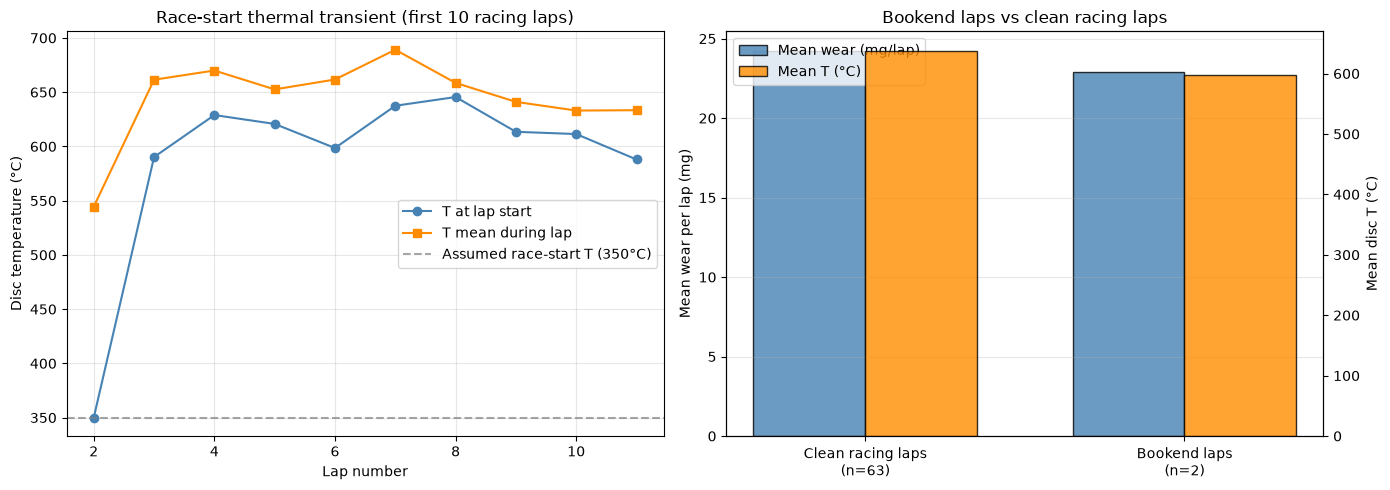


Bookend vs clean racing laps:
  Clean laps   (n=63): wear 24.25±1.13 mg, T_mean 638°C
  Bookend laps (n= 2): wear 22.89±3.48 mg, T_mean 597°C


In [4]:
#Bookend lap and first-stint transient diagnostics

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: race-start transient (stint 1, first 10 laps) ──────────────
stint1 = per_lap[per_lap['stint_seq'] == 1].head(10)
axes[0].plot(stint1['lap_number'], stint1['T_disc_start_C'],
              '-o', color='steelblue', label='T at lap start')
axes[0].plot(stint1['lap_number'], stint1['T_disc_mean_C'],
              '-s', color='darkorange', label='T mean during lap')
axes[0].axhline(350, color='gray', linestyle='--', alpha=0.7,
                 label='Assumed race-start T (350°C)')
axes[0].set_xlabel('Lap number')
axes[0].set_ylabel('Disc temperature (°C)')
axes[0].set_title('Race-start thermal transient (first 10 racing laps)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Right: bookend vs racing lap comparison ──────────────────────────
clean = per_lap[~per_lap['is_bookend_lap']]
bookend = per_lap[per_lap['is_bookend_lap']]
clean_wear = clean['wear_mech_lap_mg'] + clean['wear_ox_lap_mg']
bookend_wear = bookend['wear_mech_lap_mg'] + bookend['wear_ox_lap_mg']

categories = ['Clean racing laps', 'Bookend laps']
n_each = [len(clean), len(bookend)]
mean_wear = [clean_wear.mean(), bookend_wear.mean() if len(bookend) > 0 else 0]
mean_t = [clean['T_disc_mean_C'].mean(),
           bookend['T_disc_mean_C'].mean() if len(bookend) > 0 else 0]

x = np.arange(len(categories))
width = 0.35
axes[1].bar(x - width/2, mean_wear, width, color='steelblue',
             alpha=0.8, edgecolor='black', label='Mean wear (mg/lap)')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{c}\n(n={n})" for c, n in zip(categories, n_each)])
axes[1].set_ylabel('Mean wear per lap (mg)')
axes[1].grid(True, alpha=0.3, axis='y')
ax_twin = axes[1].twinx()
ax_twin.bar(x + width/2, mean_t, width, color='darkorange',
             alpha=0.8, edgecolor='black', label='Mean T (°C)')
ax_twin.set_ylabel('Mean disc T (°C)')
axes[1].set_title('Bookend laps vs clean racing laps')

# Combined legend
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Print bookend vs clean numerical comparison
print(f"\nBookend vs clean racing laps:")
print(f"  Clean laps   (n={len(clean):2d}): "
      f"wear {clean_wear.mean():.2f}±{clean_wear.std():.2f} mg, "
      f"T_mean {clean['T_disc_mean_C'].mean():.0f}°C")
print(f"  Bookend laps (n={len(bookend):2d}): "
      f"wear {bookend_wear.mean():.2f}±{bookend_wear.std():.2f} mg, "
      f"T_mean {bookend['T_disc_mean_C'].mean():.0f}°C")

## Summary: what this notebook established

### Model behavior under race conditions

- **Pipeline produces stable, physically plausible results across the race.** Forward integration without iteration produces results that match qualitative expectations: monotonic wear accumulation, no spurious oscillations, clean handling of pit stops and excluded laps.

- **Race-start initial condition is largely irrelevant.** The disc catches up to its quasi-steady cycle within 1 lap, not 3-5 as predicted. Our 350°C assumption being wrong by ±100°C would not change anything past lap 3. This is a useful robustness property to have documented.

- **Each stint is its own fixed point, not a drift along a trajectory.** Stints 1, 2, 3 produce flat mean disc temperatures (645, 631, 615°C respectively) with no within-stint drift. Compound + fuel mass jointly determine each stint's quasi-steady operating temperature; transitions between stints are discrete jumps to a new fixed point, not gradual drift.

### Headline finding: race vs Q3 per-lap wear gap

| Metric | Q3 pole lap | Race mean (65 laps) | Delta |
|---|---|---|---|
| Wear per lap | 27.0 mg | 24.2 mg | **-10.2%** |
| Front-axle energy per lap | 5.46 MJ | 4.81 MJ | **-11.9%** |
| Peak disc T | 798°C | 780°C | -18°C |
| Mean disc T | 715°C | 634°C | -81°C |

**Engineering claim:** single-lap Q3 analysis systematically overestimates race-stint wear by ~10-12%. The fuel-mass effect (heavier → more energy per stop) is real but is outweighed by racing-pace driving being less aggressive than Q3 push laps (lift-and-coast, regen management, tire conservation). Naive extrapolation of Q wear × N laps overstates race totals.

### The regime-flip hypothesis: not confirmed at Monaco

- Peak disc T = 780°C; below the ~900°C threshold where oxidative wear becomes significant
- Oxidative wear total: 9 µg out of 1573 mg total (0.0006%)
- Race conditions stay in the same mechanical-wear regime as qualifying
- Testing this hypothesis requires hotter tracks or fundamentally different conditions

### What did not get verified (n too small)

- **Bookend vs clean lap behavior.** Only 2 bookend laps in this race (stints 3 didn't end on a pit stop; stints with longer pit-window options would have more). Wear is 22.9±3.5 mg (bookend) vs 24.2±1.1 mg (clean) — difference not significantly larger than noise at n=2. A race with more pit stops (or analysis across multiple races) would resolve this.

- **Post-pit-stop low-energy laps.** Laps 38 and 45 (first racing laps after pit stops) show ~12% lower brake energy than steady-state, suggesting driver-style tire conservation. Two data points isn't enough to claim this is systematic.

### Decision implication for Phase 1b chunk 2

The race data does not surface an observable proxy that would give a Kalman filter a useful measurement update. Lap times are noisy and only weakly linked to disc state. Per-lap energy and event count are correlated with disc state through the same physics we already model deterministically — they wouldn't be independent measurements.

This is the diagnostic-step outcome we agreed to look at before committing to the state estimator. Going to rear brakes + MGU-K next is the right move: more novel, more 2026-specific, has structural justification regardless of available measurements.

**Phase 1b chunk 1: complete.**